### HW3: Wide data and linear models

##### Name: Ananya Agrawal
##### Andrew ID: ananyaa2

##### 38615: Computational Modelling, Statistical Analysis and Machine Learning in Science - Homework 3


#### Importing Libraries

In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, LassoCV, Lasso
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [2]:
import warnings
warnings.filterwarnings("ignore")

#### Reading the Training Set Features, Training Set Labels and Test Set Features

In [53]:
TEST_X = "f24-38615-hw3/test_X.csv"
TRAIN_X = "f24-38615-hw3/train_X.csv"
TRAIN_Y = "f24-38615-hw3/train_y.csv"

In [54]:
x = pd.read_csv(TRAIN_X).drop(columns=['Unnamed: 0']) # Dropping the first column - ID 
x

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,...,ENSG00000282651,ENSG00000282815,ENSG00000282939,ENSG00000283063,ENSG00000283439,ENSG00000283463,ENSG00000283526,ENSG00000283586,ENSG00000283632,ENSG00000283697
0,7.062725,0.026623,6.720413,5.449267,3.868619,4.587771,7.165112,4.643161,6.771731,4.750296,...,0.325987,-5.545564,-5.545564,-5.545564,-5.545564,4.014351,4.841392,-5.545564,5.855893,3.618253
1,5.965392,-5.431256,6.358498,4.161479,4.585293,4.326924,6.849703,4.391534,5.819945,3.435322,...,5.910874,-0.945029,3.750430,1.611211,-0.498573,3.430928,3.160435,-5.431256,4.413930,3.353496
2,7.892221,-5.851870,8.132992,5.986320,5.422599,4.728815,8.168477,6.289562,7.331591,5.336794,...,10.103565,-5.851870,6.498217,5.481945,-5.851870,5.137298,4.296777,-5.851870,5.345372,5.028567
3,6.826546,0.964851,5.998280,4.991435,4.963000,4.977695,7.149421,4.570863,6.008286,5.474553,...,2.442099,-5.994056,2.862038,1.909955,0.568120,4.768694,3.983207,-5.994056,4.609411,4.329472
4,7.059095,2.429954,6.746639,5.591316,5.111120,5.972938,7.576201,6.032083,6.470761,5.380887,...,5.553223,-5.870484,3.044916,-5.870484,0.018320,4.640575,4.954957,-5.870484,4.620774,4.464277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,7.009917,0.088022,6.814481,4.685804,3.039239,4.373218,6.826167,5.101784,6.327076,3.517293,...,5.244168,-5.619018,3.953899,-5.619018,-0.021027,4.055201,3.052880,-5.619018,4.560183,3.889471
440,4.772186,-5.062627,7.064273,5.505659,5.769194,4.307329,6.576986,4.018168,5.453594,3.499849,...,6.641965,-0.284152,4.238647,5.431223,0.785492,3.489883,-5.062627,-5.062627,4.467892,3.335732
441,7.741897,1.467622,6.547112,4.994184,5.273657,6.069989,7.170169,5.740295,6.115446,6.510703,...,5.963416,-5.380528,4.411300,2.265077,-5.380528,4.727461,4.502798,-5.380528,4.102909,4.326804
442,5.774051,-6.793718,7.218590,5.477760,5.042350,3.700158,7.349451,4.573089,6.003810,4.067563,...,6.036861,-6.793718,3.605128,2.503595,-6.793718,3.401223,4.962133,-6.793718,3.864213,3.200419


In [55]:
y = pd.read_csv(TRAIN_Y).drop(columns=['Unnamed: 0']) # Dropping the first column - ID 
y

,xml_neoplasm_histologic_grade
0,0
1,1
2,0
3,0
4,1
...,...
439,1
440,1
441,1
442,0


#### Exploring the data

In [6]:
x.describe()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,...,ENSG00000282651,ENSG00000282815,ENSG00000282939,ENSG00000283063,ENSG00000283439,ENSG00000283463,ENSG00000283526,ENSG00000283586,ENSG00000283632,ENSG00000283697
count,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,...,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000
mean,6.798864,-1.251875,6.867482,5.092604,4.249074,4.951573,7.179084,5.241762,6.152933,4.498626,...,3.650685,-4.019460,2.852973,0.532640,-3.685311,4.131878,3.000574,-5.558757,4.313466,3.944751
std,0.657958,3.487385,0.649468,0.557108,0.974955,1.245837,0.635931,0.803235,0.556726,0.770503,...,3.537927,2.779953,2.558302,3.758160,2.842395,0.743549,2.396337,1.893713,0.798173,0.755219
min,3.865658,-8.167826,3.921938,2.686933,0.635382,1.559740,4.091881,1.961100,3.491674,0.877428,...,-8.025671,-8.093499,-7.791345,-7.821501,-8.093499,1.289553,-7.174879,-8.167826,-0.430043,0.899681
25%,6.447793,-5.483300,6.546906,4.765809,3.630805,4.075300,6.844709,4.783474,5.828785,4.045615,...,2.240973,-5.966191,2.295934,-0.131155,-5.899284,3.706238,1.768129,-6.599244,3.882128,3.511135
50%,6.852772,0.213298,6.938184,5.093077,4.238058,4.896219,7.207127,5.155404,6.157952,4.492328,...,4.101297,-5.425883,3.333111,1.984213,-5.168411,4.119857,3.473621,-5.861161,4.348660,3.944781
75%,7.226415,1.184977,7.269660,5.435893,4.935047,5.948701,7.594792,5.664817,6.468815,4.950106,...,5.794548,-1.497067,4.331129,3.146919,-0.619910,4.611680,4.724469,-5.445569,4.810073,4.425701
max,8.642886,9.451403,8.598549,6.988089,7.650225,8.220311,8.916491,8.810685,7.702358,7.233636,...,12.370689,5.137566,7.188701,7.083282,2.026253,6.738504,7.181350,1.982121,6.661020,6.684243


In [7]:
y.describe()

,xml_neoplasm_histologic_grade
count,444.000000
mean,0.572072
std,0.495336
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [8]:
print(x.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Columns: 17970 entries, ENSG00000000003 to ENSG00000283697
dtypes: float64(17970)
memory usage: 60.9 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 1 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   xml_neoplasm_histologic_grade  444 non-null    int64
dtypes: int64(1)
memory usage: 3.6 KB
None


In [9]:
print(x.dtypes)
print(y.dtypes)

ENSG00000000003    float64
ENSG00000000005    float64
ENSG00000000419    float64
ENSG00000000457    float64
ENSG00000000938    float64
                    ...   
ENSG00000283463    float64
ENSG00000283526    float64
ENSG00000283586    float64
ENSG00000283632    float64
ENSG00000283697    float64
Length: 17970, dtype: object
xml_neoplasm_histologic_grade    int64
dtype: object


In [10]:
check_null = x.isnull().sum()
null_rows_with_data = check_null[check_null > 0]  # Filter only rows with null values
print(null_rows_with_data)
check_null = y.isnull().sum()
null_rows_with_data = check_null[check_null > 0]  # Filter only rows with null values
print(null_rows_with_data)

Series([], dtype: int64)
Series([], dtype: int64)


#### Finding Outliers

In [11]:
total_outliers = 0
dataset_filtered = x

for column in x:
  Q1 = x[column].quantile(0.25)
  Q3 = x[column].quantile(0.75)
  IQR = Q3 - Q1

  # extending the range of IQR for identifying outliers in the given dataset from 1.5 times to 6 times
  lower_bound = Q1 - 6 * IQR
  upper_bound = Q3 + 6 * IQR

  outliers = x[(x[column] < lower_bound) | (x[column] > upper_bound)]
  total_outliers += len(outliers[column])
  dataset_filtered = dataset_filtered[(dataset_filtered[column] >= lower_bound) & (dataset_filtered[column] <= upper_bound)]

avg_outliers = (total_outliers / len(x))
print("Average number of Outliers detected per column ", avg_outliers)

Average number of Outliers detected per column  8.457207207207206


#### Performing Binary Classification (0/1) using Linear Models

In [12]:
test_x = pd.read_csv(TEST_X)
tt_x = test_x.drop(columns=['Unnamed: 0'])
tt_x

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,...,ENSG00000282651,ENSG00000282815,ENSG00000282939,ENSG00000283063,ENSG00000283439,ENSG00000283463,ENSG00000283526,ENSG00000283586,ENSG00000283632,ENSG00000283697
0,7.503849,1.685440,8.090089,5.546588,3.412025,5.871539,8.395029,5.894996,6.313896,4.286261,...,3.626396,-2.640463,-7.278265,0.721287,-7.278265,4.672536,5.153675,-7.278265,4.843800,4.302864
1,6.112919,-5.425877,5.604743,4.248246,3.374033,3.370075,6.804015,4.646287,6.236134,4.167541,...,-5.425877,-2.143410,1.956699,1.377768,-5.425877,4.560829,3.735085,-5.425877,4.105789,4.803357
2,6.183846,1.217355,6.093903,4.403216,5.722867,6.123209,7.680258,4.983386,5.626569,3.518791,...,11.317818,-5.259782,5.093316,3.800607,-5.259782,4.966710,2.829487,-5.259782,5.118704,5.024979
3,6.325535,-0.197432,6.722632,4.509093,4.941256,3.700171,7.492606,5.031053,5.859242,4.252114,...,3.536141,-1.362703,3.480703,0.776383,-0.999629,4.794226,-5.399485,-5.399485,4.660878,4.684343
4,7.162383,-5.539710,6.186110,5.270282,5.412103,3.781568,7.285779,4.847552,6.337205,5.622222,...,5.112772,-5.539710,4.369268,2.927849,0.791397,4.542333,4.628775,-5.539710,4.812787,4.524834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,6.949029,2.192625,7.613706,5.131517,4.292879,5.337764,7.668408,5.159289,5.645662,3.082916,...,5.515318,-5.785898,4.229114,2.875184,-0.303496,3.322246,3.683199,-5.785898,4.730559,3.251810
106,7.419322,0.472349,6.723539,5.176782,4.297442,4.591905,7.171547,6.693665,5.782247,5.965700,...,2.737453,-1.781791,3.509502,0.021815,-6.758708,4.684549,4.795272,-6.758708,4.234056,4.614238
107,7.135800,0.479097,7.051451,6.042828,4.523706,7.250545,7.577726,5.622388,6.447874,4.835028,...,5.951147,-5.960456,4.025253,2.785925,-5.960456,4.236003,5.597498,-5.960456,5.279498,3.813894
108,6.859635,2.159767,7.254992,4.900402,4.256251,6.503227,6.810730,6.036136,6.282137,4.745579,...,4.462337,-5.553034,4.325258,2.593648,-5.553034,4.727639,2.380364,-5.553034,5.523681,4.088765


In [13]:
# Taking X and Y for the data arrays
# Splitting the training dataset into training and validation sets considering 70% is training and 30% is validation
X_train, X_val, Y_train, Y_val = train_test_split(x, y, test_size=0.3, random_state=101) # maintaining a random state for reproducibility

#### Pipeline to try different linear models

In [14]:
# Initialize models to be tested in a pipeline
models = {
    'Linear Regression': LinearRegression(),
    'Logistic Regression (L1 regularization)': LogisticRegression(penalty='l1', solver='saga', max_iter=50000),
    'Logistic Regression (L2 regularization)': LogisticRegression(penalty='l2', solver='saga', max_iter=50000), 
    'Logistic Regression (L1 + L2 regularization)': LogisticRegression(penalty='elasticnet', solver='saga', C=0.1, l1_ratio=0.5, max_iter=50000),
    'Ridge Classifier': RidgeClassifier(),
    'Lasso (as Logistic)': Lasso(max_iter=50000),
    'Support Vector Classifier': SVC(kernel='linear')
}

# Define a function to evaluate models
def evaluate_model(model, X_train, X_val, Y_train, Y_val, threshold=0.5):
    # Fit the model
    model.fit(X_train, Y_train)
    
    # Predict on validation set
    if isinstance(model, (LinearRegression, Lasso)):
        # Get continuous predictions and convert to binary
        y_pred = model.predict(X_val)
        y_pred = np.where(y_pred >= threshold, 1, 0)
    else:
        # Direct binary predictions for classifiers
        y_pred = model.predict(X_val)
    
    # Compute accuracy and F1-score
    accuracy = accuracy_score(Y_val, y_pred)
    f1 = f1_score(Y_val, y_pred)
    
    return accuracy, f1


#### Evaluating the effect of regularization parameter(s) on model performance.

In [15]:
# Evaluate each model
results = {}
for model_name, model in models.items():
    print("Evaluating : " + model_name)
    accuracy, f1 = evaluate_model(model, X_train, X_val, Y_train, Y_val)
    results[model_name] = {'Accuracy': accuracy, 'F1-score': f1}

results

Evaluating : Linear Regression
Evaluating : Logistic Regression (L1 regularization)
Evaluating : Logistic Regression (L2 regularization)
Evaluating : Logistic Regression (L1 + L2 regularization)
Evaluating : Ridge Classifier
Evaluating : Lasso (as Logistic)
Evaluating : Support Vector Classifier


{'Linear Regression': {'Accuracy': 0.7686567164179104,
  'F1-score': np.float64(0.7862068965517242)},
 'Logistic Regression (L1 regularization)': {'Accuracy': 0.753731343283582,
  'F1-score': np.float64(0.7659574468085106)},
 'Logistic Regression (L2 regularization)': {'Accuracy': 0.7835820895522388,
  'F1-score': np.float64(0.8)},
 'Logistic Regression (L1 + L2 regularization)': {'Accuracy': 0.7313432835820896,
  'F1-score': np.float64(0.7464788732394366)},
 'Ridge Classifier': {'Accuracy': 0.7686567164179104,
  'F1-score': np.float64(0.7862068965517242)},
 'Lasso (as Logistic)': {'Accuracy': 0.5298507462686567,
  'F1-score': np.float64(0.6926829268292682)},
 'Support Vector Classifier': {'Accuracy': 0.7761194029850746,
  'F1-score': np.float64(0.7945205479452054)}}

#### Best Model: Logistic Regression (L2 regularization)

#### Evaluating the model with Scaling

In [16]:
# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [17]:
# Evaluate each model
results_scaled = {}
for model_name, model in models.items():
    print("Evaluating : " + model_name)
    accuracy, f1 = evaluate_model(model, X_train_scaled, X_val_scaled, Y_train, Y_val)
    results_scaled[model_name] = {'Accuracy': accuracy, 'F1-score': f1}

results_scaled

Evaluating : Linear Regression
Evaluating : Logistic Regression (L1 regularization)
Evaluating : Logistic Regression (L2 regularization)
Evaluating : Logistic Regression (L1 + L2 regularization)
Evaluating : Ridge Classifier
Evaluating : Lasso (as Logistic)
Evaluating : Support Vector Classifier


{'Linear Regression': {'Accuracy': 0.7686567164179104,
  'F1-score': np.float64(0.7801418439716312)},
 'Logistic Regression (L1 regularization)': {'Accuracy': 0.7388059701492538,
  'F1-score': np.float64(0.7368421052631579)},
 'Logistic Regression (L2 regularization)': {'Accuracy': 0.7388059701492538,
  'F1-score': np.float64(0.732824427480916)},
 'Logistic Regression (L1 + L2 regularization)': {'Accuracy': 0.753731343283582,
  'F1-score': np.float64(0.7591240875912408)},
 'Ridge Classifier': {'Accuracy': 0.7686567164179104,
  'F1-score': np.float64(0.7801418439716312)},
 'Lasso (as Logistic)': {'Accuracy': 0.5298507462686567,
  'F1-score': np.float64(0.6926829268292682)},
 'Support Vector Classifier': {'Accuracy': 0.7611940298507462,
  'F1-score': np.float64(0.7746478873239436)}}

#### Comparing the best model accuracy with random guessing 

In [18]:
def evaluate_with_randomization(model, X_train, X_val, Y_train, Y_val, n_randomizations=3):
    # Train and evaluate model on real labels
    model.fit(X_train, Y_train)
    y_pred_real = model.predict(X_val)
    accuracy_real = accuracy_score(Y_val, y_pred_real)
    f1_real = f1_score(Y_val, y_pred_real)
    
    # Initialize list to store accuracy scores for random labels
    random_accuracies = []
    random_f1s = []
    
    # Perform Y-randomization (scramble labels) and evaluate
    for _ in range(n_randomizations):
        # Shuffle the labels
        Y_train_random = np.random.permutation(Y_train)
        
        # Train and evaluate the model on randomized labels
        model.fit(X_train, Y_train_random)
        y_pred_random = model.predict(X_val)
        random_accuracy = accuracy_score(Y_val, y_pred_random)
        random_f1 = f1_score(Y_val, y_pred_random)
        random_accuracies.append(random_accuracy)
        random_f1s.append(random_f1)
    
    # Calculate the mean random guessing accuracy and F1 score
    mean_random_accuracy = np.mean(random_accuracies)
    mean_random_f1 = np.mean(random_f1s)

    
    return accuracy_real, f1_real, mean_random_accuracy, mean_random_f1


In [19]:
evaluate_with_randomization(models['Logistic Regression (L2 regularization)'], X_train, X_val, Y_train, Y_val)

(0.7835820895522388,
 np.float64(0.8),
 np.float64(0.47014925373134325),
 np.float64(0.5723346798050722))

#### Which genes are the most important for model decision? - Evaluating using Feature Selection

#### 1. LassoCV

In [20]:
# Apply LASSOCV for feature selection
lasso = LassoCV(cv=5, random_state=101, max_iter=50000)
lasso.fit(X_train, Y_train)

LassoCV(cv=5, max_iter=50000, random_state=101)

In [21]:
lasso_sorted = np.argsort(np.abs(lasso.coef_))
print(lasso_sorted[:10000])

[    0 11963 11964 ...  2532  2533  2534]


In [22]:
# Evaluating the best model with feature selection using LassoCV
log_reg = LogisticRegression(penalty='l2', solver='saga', max_iter=50000)
log_reg.fit(X_train.iloc[:,lasso_sorted[:10000]], Y_train)

y_pred = log_reg.predict(X_val.iloc[:,lasso_sorted[:10000]])
accuracy = accuracy_score(Y_val, y_pred)
f1 = f1_score(Y_val, y_pred)
print(f"Accuracy with Logistic Regression: {accuracy:.4f}")
print(f"F1 Score with Logistic Regression: {f1:.4f}")



Accuracy with Logistic Regression: 0.7463
F1 Score with Logistic Regression: 0.7606


#### 2. Select K best

In [56]:
#using mutual_info_classif for classification problem MI

mi_scores = mutual_info_classif(x, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=x.columns)
mi_scores = mi_scores.sort_values(ascending=False)

mi_scores # show a few features with their MI scores

ENSG00000101443    0.155406
ENSG00000101448    0.155007
ENSG00000163071    0.150078
ENSG00000243543    0.149875
ENSG00000103056    0.145172
                     ...   
ENSG00000166135    0.000000
ENSG00000166130    0.000000
ENSG00000166128    0.000000
ENSG00000102974    0.000000
ENSG00000167037    0.000000
Name: MI Scores, Length: 17970, dtype: float64

In [57]:
mi_scores.index

Index(['ENSG00000101443', 'ENSG00000101448', 'ENSG00000163071',
       'ENSG00000243543', 'ENSG00000103056', 'ENSG00000163501',
       'ENSG00000187980', 'ENSG00000016402', 'ENSG00000165188',
       'ENSG00000124939',
       ...
       'ENSG00000166167', 'ENSG00000166165', 'ENSG00000166159',
       'ENSG00000166148', 'ENSG00000166143', 'ENSG00000166135',
       'ENSG00000166130', 'ENSG00000166128', 'ENSG00000102974',
       'ENSG00000167037'],
      dtype='object', length=17970)

In [58]:
use_features = []
for index, feat in enumerate(mi_scores):
    if feat > 0:
        use_features.append(feat)
print(len(use_features))

13054


In [59]:
# Evaluating Model
k = len(use_features)  # Specify the number of features 
selector = SelectKBest(score_func=f_classif, k=k)
X_train_selected = selector.fit_transform(X_train, Y_train)
X_test_selected = selector.transform(X_val)

log_reg_k = LogisticRegression(penalty='l2', solver='saga', max_iter=50000)  # max_iter increased for convergence
log_reg_k.fit(X_train_selected, Y_train)

y_pred = log_reg_k.predict(X_test_selected)
accuracy = accuracy_score(Y_val, y_pred)
f1 = f1_score(Y_val, y_pred)
print(f"Accuracy with Logistic Regression: {accuracy:.4f}")
print(f"F1 Score with Logistic Regression: {f1:.4f}")

Accuracy with Logistic Regression: 0.7761
F1 Score with Logistic Regression: 0.7857


#### 3. Principal Component Analysis

In [27]:
# Apply PCA for dimensionality reduction
# Retaining 95% of variance 
pca = PCA(n_components=0.95, random_state=101)  # Adjustign n_components based on preference

# Fit PCA on the training data and transform both training and test data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_val)

In [28]:
# Evaluating Model
log_reg = LogisticRegression(penalty='l2', solver='saga', max_iter=50000)  # max_iter increased for convergence
log_reg.fit(X_train_pca, Y_train)

y_pred = log_reg.predict(X_test_pca)
accuracy = accuracy_score(Y_val, y_pred)
f1 = f1_score(Y_val, y_pred)
print(f"Accuracy with Logistic Regression: {accuracy:.4f}")
print(f"F1 Score with Logistic Regression: {f1:.4f}")

Accuracy with Logistic Regression: 0.7463
F1 Score with Logistic Regression: 0.7463


#### Most Important Genes as observed from Select K Best model performance

In [60]:
imp_genes = []
for index, gene in enumerate(mi_scores):
    if gene > 0:
        imp_genes.append(mi_scores.index[index])
print(imp_genes)

['ENSG00000101443', 'ENSG00000101448', 'ENSG00000163071', 'ENSG00000243543', 'ENSG00000103056', 'ENSG00000163501', 'ENSG00000187980', 'ENSG00000016402', 'ENSG00000165188', 'ENSG00000124939', 'ENSG00000186910', 'ENSG00000116299', 'ENSG00000108342', 'ENSG00000146021', 'ENSG00000082175', 'ENSG00000138449', 'ENSG00000187908', 'ENSG00000189157', 'ENSG00000225366', 'ENSG00000157315', 'ENSG00000215018', 'ENSG00000135063', 'ENSG00000053900', 'ENSG00000124664', 'ENSG00000142494', 'ENSG00000072858', 'ENSG00000180347', 'ENSG00000272804', 'ENSG00000163406', 'ENSG00000153246', 'ENSG00000100665', 'ENSG00000183346', 'ENSG00000154556', 'ENSG00000257115', 'ENSG00000069535', 'ENSG00000184709', 'ENSG00000154133', 'ENSG00000168528', 'ENSG00000112530', 'ENSG00000111247', 'ENSG00000120262', 'ENSG00000137860', 'ENSG00000159714', 'ENSG00000085465', 'ENSG00000170099', 'ENSG00000188761', 'ENSG00000099326', 'ENSG00000069696', 'ENSG00000082512', 'ENSG00000107611', 'ENSG00000084764', 'ENSG00000110484', 'ENSG000001

#### Visualizing the dataset so as to visually separate two groups of patients.

Cluster 0 features:
      ENSG00000000003  ENSG00000000005  ENSG00000000419  ENSG00000000457  \
1           5.965392        -5.431256         6.358498         4.161479   
5           6.997665         0.408897         6.806843         4.668248   
6           6.703820         2.819784         6.429305         4.302222   
7           6.155266        -0.557874         6.377303         4.519077   
8           5.638687         1.588356         5.251512         2.857674   
..               ...              ...              ...              ...   
407         6.485208        -5.753306         5.837926         4.573758   
420         6.779723         5.738992         6.888091         4.365774   
422         6.557242         3.195405         7.162823         4.995293   
434         6.335585         1.660255         5.508904         4.698081   
439         7.009917         0.088022         6.814481         4.685804   

     ENSG00000000938  ENSG00000000971  ENSG00000001036  ENSG00000001084  \
1  

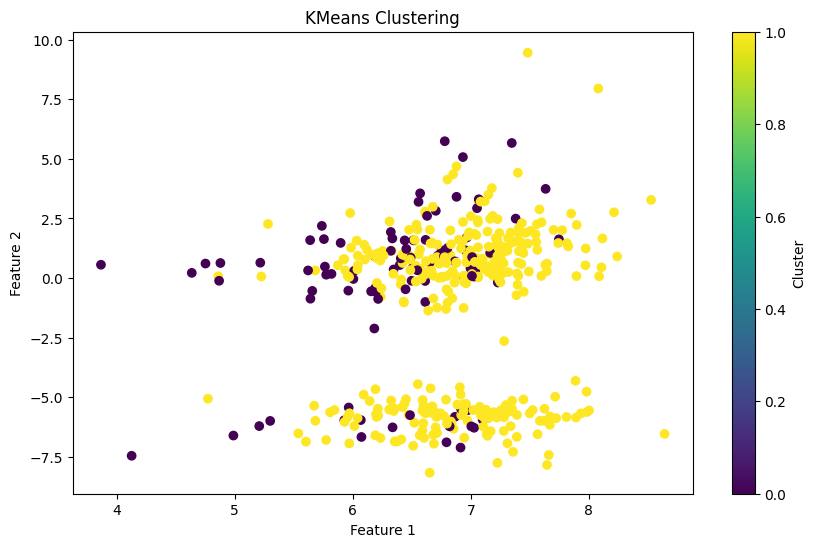

In [70]:
# x is the dataframe with the features to cluster
# Apply KMeans
kmeans = KMeans(n_clusters=2, random_state=101)
kmeans.fit(x,y)

# Add the cluster labels to the original dataframe
x['cluster'] = kmeans.labels_

# Print the features that were separated in each cluster
for cluster in range(2):
    print(f"Cluster {cluster} features:\n", x[x['cluster'] == cluster], "\n")

# Plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=x['cluster'], cmap='viridis', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering')
plt.colorbar(label='Cluster')
plt.show()


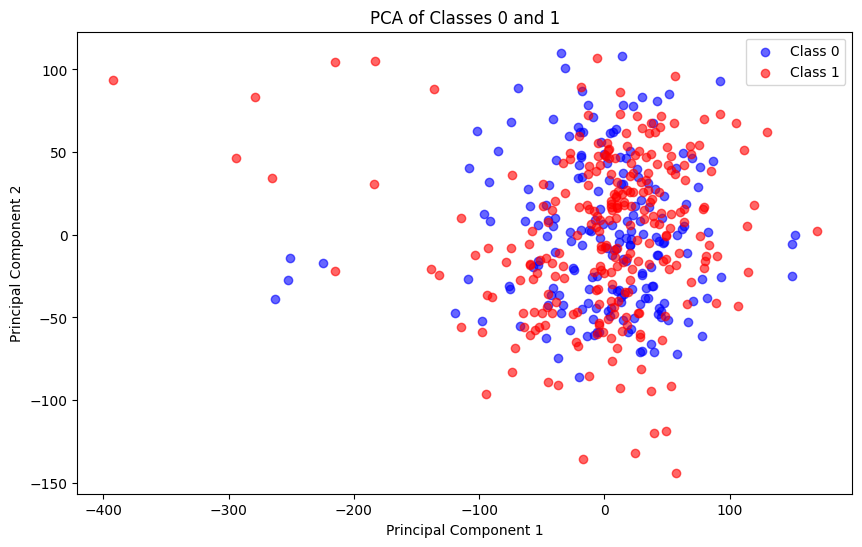

In [31]:
# x and y are the dataframes
# Separate the data in x based on values in y
x_0 = x[y.iloc[:, 0] == 0]  # Rows in x where y is 0
x_1 = x[y.iloc[:, 0] == 1]  # Rows in x where y is 1

# Perform PCA to reduce to 2 dimensions for both sets
pca = PCA(n_components=2)
x_0_pca = pca.fit_transform(x_0)
x_1_pca = pca.fit_transform(x_1)

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(x_0_pca[:, 0], x_0_pca[:, 1], color='blue', label='Class 0', alpha=0.6)
plt.scatter(x_1_pca[:, 0], x_1_pca[:, 1], color='red', label='Class 1', alpha=0.6)
plt.title("PCA of Classes 0 and 1")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


Cluster 0 features:
      ENSG00000000003  ENSG00000000005  ENSG00000000419  ENSG00000000457  \
0           7.062725         0.026623         6.720413         5.449267   
1           5.965392        -5.431256         6.358498         4.161479   
2           7.892221        -5.851870         8.132992         5.986320   
5           6.997665         0.408897         6.806843         4.668248   
6           6.703820         2.819784         6.429305         4.302222   
..               ...              ...              ...              ...   
437         7.387357        -0.720258         7.779666         5.495556   
438         7.311065        -6.933301         8.391138         5.259715   
439         7.009917         0.088022         6.814481         4.685804   
440         4.772186        -5.062627         7.064273         5.505659   
443         6.862574        -0.192592         7.746075         4.776227   

     ENSG00000000938  ENSG00000000971  ENSG00000001036  ENSG00000001084  \
0  

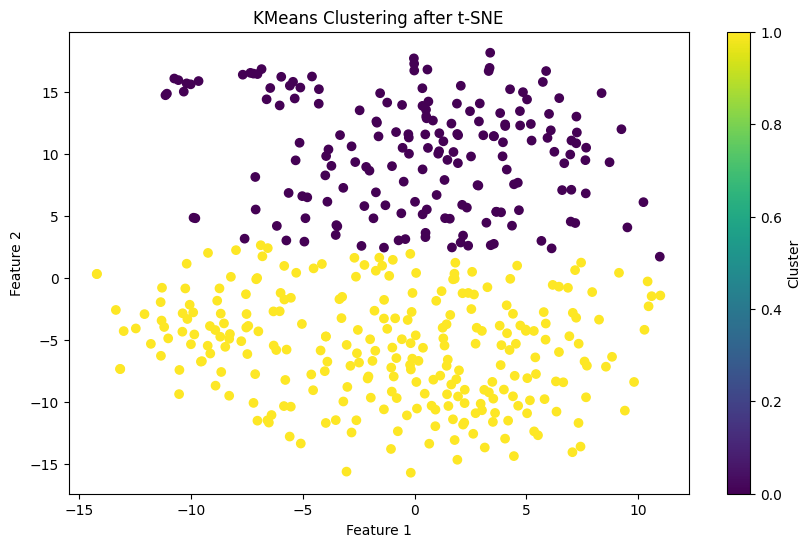

In [69]:
# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=101)
x_tsne = tsne.fit_transform(x)

# Apply KMeans clustering on the t-SNE output
kmeans = KMeans(n_clusters=2, random_state=101)
kmeans.fit(x_tsne)

# Add the cluster labels to the t-SNE DataFrame
tsne_df = pd.DataFrame(x_tsne, columns=['Feature 1', 'Feature 2'])
tsne_df['cluster'] = kmeans.labels_

# Print the features that were separated in each cluster
for cluster in range(2):
    print(f"Cluster {cluster} features:\n", x[tsne_df['cluster'] == cluster], "\n")

# Plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(tsne_df['Feature 1'], tsne_df['Feature 2'], c=tsne_df['cluster'], cmap='viridis', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering after t-SNE')
plt.colorbar(label='Cluster')
plt.show()


#### Top 10 genes

In [61]:
imp_genes[:10]

['ENSG00000101443',
 'ENSG00000101448',
 'ENSG00000163071',
 'ENSG00000243543',
 'ENSG00000103056',
 'ENSG00000163501',
 'ENSG00000187980',
 'ENSG00000016402',
 'ENSG00000165188',
 'ENSG00000124939']

In [62]:
output = imp_genes[:] # mapping for all important genes

In [63]:
# Specify the file path and name
file_path = "output.txt"

# Open the file in write mode and write the content
with open(file_path, "w") as file:
    for line in output:
        file.write(line + "\n")  # Add a newline after each line

print(f"Output written to {file_path}")

Output written to output.txt


#### Bonus Question 

Results for  all 13054 important genes: ID mapping 51,801 results found for Ensembl → UniProtKB, 12,739 IDs were mapped to 51,801 results
315 ID were not mapped

Results for first 10 important genes: ID mapping 22 results found for Ensembl → UniProtKB, 10 IDs were mapped to 22 results

First 10 genes:
1. ENSG00000101443
2. ENSG00000101448
3. ENSG00000163071
4. ENSG00000243543
5. ENSG00000103056
6. ENSG00000163501
7. ENSG00000187980
8. ENSG00000016402
9. ENSG00000165188
10. ENSG00000124939

The ten most significant genes associated with UCEC include:

1. ENSG00000141510 (TP53) - Known for tumor suppression.
2. ENSG00000171862 (PTEN) - Frequently mutated in UCEC, impacting cell cycle control.
3. ENSG00000121879 (PIK3CA) - Plays a role in cell growth and survival.
4. ENSG00000163513 (ARID1A) - Related to chromatin remodeling and often mutated in endometrial cancers.
5. ENSG00000163631 (CTNNB1) - Involved in Wnt signaling, critical in cancer progression.
6. ENSG00000163597 (TTN) - Commonly mutated in various cancers, including UCEC.
7. ENSG00000186092 (BUB1) - Associated with cell cycle regulation and poor prognosis in high-grade tumors.
8. ENSG00000118007 (HDGF) - A gene involved in angiogenesis, correlating with higher tumor grade.
9. ENSG00000101347 (AURKA) - A mitotic regulator, its expression relates to poor survival rates.
10. ENSG00000136244 (MUC16) - Mutation impacts immune response and is noted in high-grade tumors.

These genes are known for their impact on tumor grade, especially between Grade II and III tumors


#### Constructing the submission for Kaggle on Test_X

In [64]:
x_new_test = selector.transform(tt_x)
y_pred = log_reg_k.predict(x_new_test)
y_pred

array([1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1])

In [65]:
preds = pd.DataFrame(y_pred)
output = pd.concat([test_x['Unnamed: 0'], preds], axis=1)
# Rename the first column
output.rename(columns={output.columns[0]: 'ID', output.columns[1]: 'xml_neoplasm_histologic_grade'}, inplace=True)
output.to_csv('test_output.csv', index=False)

### Write up:

The dataset for 554 patients was given, here 80% (444 patients) of the dataset was selected to be the training set, and 20% (110 patients) as the test set. 

train_X.csv contained the features, and train_y.csv contained the labels. Features of the test set were present in test_X.csv while labels were hidden.

In order to predict the disease type (phenotype) from transcriptomics data. Disease: UCEC (uterine corpus endometrial carcinoma), where Labels (0/1) are encoding tumor grade “II-” vs. “III+”, I first explored the given dataset to find that there were no Null values however around 8 outliers were present in each feature column.

Starting with the binary classification, I first split the training data into training and validation dataset where 70% was used for training and 30% was used for validation.

Building a pipeline of linear models to evaluate the validation dataset resulted in higher accuracy and F1 scores for the Logistic Regression Model with L2 regularization which meant that regularization of the data improved the model performance.

It is also observed that upon scaling the data, the model performance for Logistic Regression with L2 regularization dropped however for L1 and L2 regularization the model performance improved. For all other models such as Ridge Classifier and Support Vector Classifier, the performance remained the same.

On applying random guessing to Logistic Regression Model with l2 regularization, the model performance was not as affected as much as it was after scaling thereby making it the best model to consider for Binary Classification.

Next, in order to decide which genes were most important, feature selection was done using LassoCV, SelectKbest and PCA to find that SelectkBest performed better and filtered around 13054 important genes that mapped to ~51,000 results when their association was checked with the disease.

The visualization of these results yield an analysis that it is not possible to visually separate the two groups of patients without doing dimensionality reduction as they have overlapping features when principal features were extracted using PCA for the visualization.

However, on applying TSNE for dimensionality reduction, the clusters are able to get visually separated as it allows the visualization of clusters in a lower-dimensional space for better separability of the clusters.

On selecting the top 10 most important genes, they mapped to 22 results showing a strong association with the disease which the model was able to capture and summarize as given above.

After testing the model performance on the validation set, the model was tested for its performance on the test set on Kaggle, and with some hyperparameter tuning, F1 scores of 90% and above were gathered. 

The evaluation metric on kagge is mean F1-score (sklearn.metrics.f1_score), which measures accuracy using the statistics precision and recall.

The F1 metric weights recall and precision equally, therefore, a good F1 score is observed thereby maximizing both precision and recall simultaneously. The selected model hence, has a moderately good performance using Logistic Regression with L2 regularization and feature selection with SelectKbest.

